step 1: import all required libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

step 2: loading the dataset 

In [3]:
df = pd.read_csv("D:\machine learning\machine_learning\decsion_tree_project\ev__battery_life\dataset\processed_data\cleaned_ev_battery_dataset.csv")
df

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,battery_chemistry_NCA,battery_chemistry_NMC,drive_type_FWD,drive_type_RWD,fleet_or_private_Private,terrain_type_Desert,terrain_type_Flat,terrain_type_Hilly,terrain_type_Mountainous,battery_failure
0,2019.0,82.54,98163.0,6.94,250.0,73.61,85.23,26.34,72.93,3.3558,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0
1,2018.0,64.17,113600.0,7.79,256.0,85.77,49.12,44.83,86.71,3.3658,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,2018.0,90.92,242253.0,7.85,556.0,72.37,54.94,33.65,72.17,3.4152,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
3,2022.0,47.35,83700.0,6.34,353.0,85.11,54.32,37.73,91.05,3.4202,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,2015.0,68.04,88784.0,11.13,287.0,87.40,62.73,65.29,86.17,3.4556,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,2016.0,45.99,182311.0,10.11,817.0,86.91,30.51,42.42,84.85,2.8901,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0
199996,2015.0,67.65,275317.0,11.06,840.0,65.08,77.61,30.76,65.08,3.5707,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
199997,2020.0,98.08,158747.0,4.89,336.0,86.08,44.59,24.64,84.90,2.9875,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
199998,2016.0,51.49,95122.0,10.06,392.0,76.61,80.70,41.93,75.50,3.5698,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0


step 3: seprate target and features 

In [4]:
X = df.drop("battery_failure", axis=1)

y = df["battery_failure"]

Step 4: Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
print(X_train.shape)
print(X_test.shape)

(160000, 156)
(40000, 156)


step 5: building first descion tree 

In [11]:
dt = DecisionTreeClassifier(
    max_depth=10,             # Stops the tree from growing deeper than 10 levels
    min_samples_leaf=5,       # Forces every final leaf to have at least 5 battery records
    class_weight="balanced",  # Handles your 90/10 class imbalance
    random_state=42
)

step 6: train model

In [12]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Step 7: Prediction

In [13]:
y_pred = dt.predict(X_test)

step 8: training accuracy

In [14]:
train_prediction = dt.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

print(train_accuracy)

0.93893125


step 9: testing accuracy

In [15]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(test_accuracy)

0.922075


step 10: compaire train vs test accuracy 

In [16]:
print(f"Training Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy : 0.9389
Testing Accuracy : 0.9221


step 11:precision 

In [17]:
precision = precision_score(
    y_test,
    y_pred
)

print(precision)

0.5679360601786554


step 12: recall

In [18]:
recall = recall_score(
    y_test,
    y_pred
)

print(recall)

0.9096385542168675


step 13: f1 score 

In [19]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f1)

0.6992764109985529


Step 14: ROC-AUC Score

In [20]:
probability = dt.predict_proba(X_test)[:,1]

roc = roc_auc_score(
    y_test,
    probability
)

print(roc)

0.9352298374696029


step 15: classification report 

In [21]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     36016
           1       0.57      0.91      0.70      3984

    accuracy                           0.92     40000
   macro avg       0.78      0.92      0.83     40000
weighted avg       0.95      0.92      0.93     40000



step 16: confusion matrix 

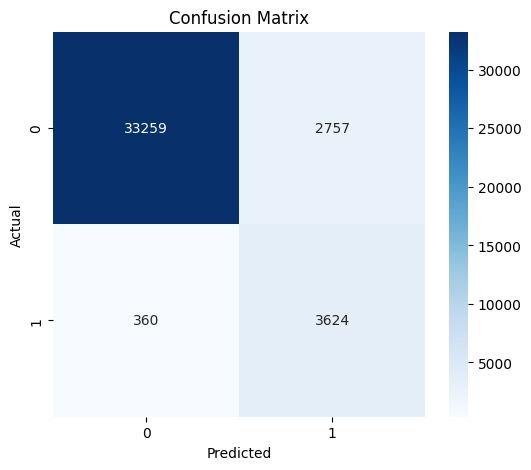

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Step 17: ROC Curve

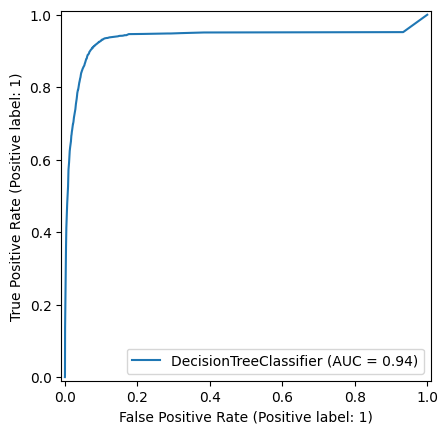

In [23]:
RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.show()

step 18: feature importance 

In [24]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [25]:
importance.head(20)

,Feature,Importance
5,battery_health_percent,0.676039
10,cell_voltage_std,0.079312
53,battery_stress_index,0.047484
56,charging_quality_score,0.040823
18,capacity_loss_percent,0.027102
48,voltage_imbalance,0.019466
43,cooling_system_health,0.018163
51,BMS_warning_count,0.016101
46,maintenance_score,0.011661
55,thermal_health_score,0.006864


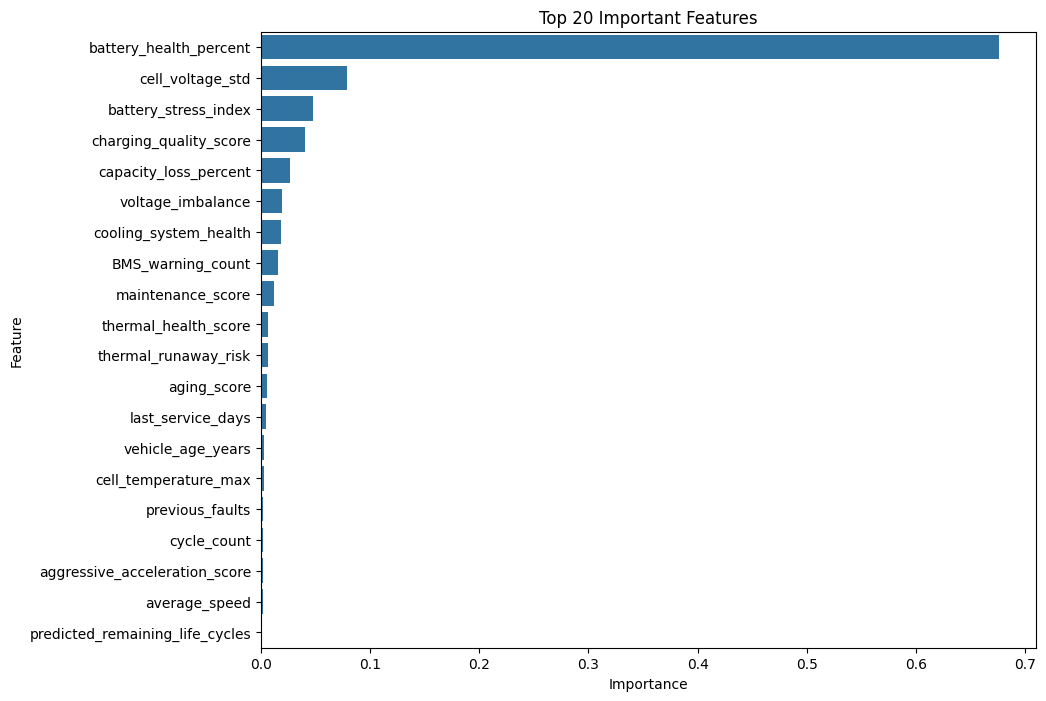

In [26]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

step 19: save the model

In [29]:
joblib.dump(
    dt,
    "D:\machine learning\machine_learning\decsion_tree_project\ev__battery_life\model/decision_tree_model.joblib"
)

['D:\\machine learning\\machine_learning\\decsion_tree_project\\ev__battery_life\\model/decision_tree_model.joblib']

Step 20: Save Feature Importance

In [31]:
importance.to_csv(
    "D:\machine learning\machine_learning\decsion_tree_project\ev__battery_life\model/feature_importance.csv",
    index=False
)

## Summary

✔ Loaded the cleaned dataset.

✔ Split the data using stratified sampling.

✔ Built a baseline Decision Tree classifier.

✔ Trained the model and generated predictions.

✔ Evaluated performance using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Classification Report

✔ Identified the most important features influencing battery failure.

✔ Visualized the top levels of the decision tree.

✔ Saved the trained model and feature importance results.

### Next Notebook

**05_Model_Optimization_and_Evaluation.ipynb**

We will:
- Tune hyperparameters with `GridSearchCV` or `RandomizedSearchCV`
- Apply SMOTE to address class imbalance
- Compare performance before and after balancing
- Reduce overfitting through pruning
- Select the best-performing Decision Tree model